In [1]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from sklearn.cluster import DBSCAN
from sklearn.neighbors import BallTree
import warnings
warnings.filterwarnings('ignore')

# Paths
RAW_DATA_DIR = os.path.expanduser("/home/du2/22CS30034/karan/GIS/lubesh")
PROJECT_DIR = os.path.expanduser("/home/du2/22CS30034/karan/GIS/lubesh")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
EARTH_RADIUS_METERS = 6371008.8

In [2]:
def parse_data():
    rest_files = glob.glob(os.path.join(RAW_DATA_DIR, "*RestPoints*.tab"))
    path_files = glob.glob(os.path.join(RAW_DATA_DIR, "*Paths*.tab"))
    
    df_rest = pd.read_csv(rest_files[0], sep="\t", low_memory=False) if rest_files else pd.DataFrame()
    df_path = pd.read_csv(path_files[0], sep="\t", low_memory=False) if path_files else pd.DataFrame()

    if not df_rest.empty:
        # Extract location, time, weather, and behavioral features
        df_rest = pd.DataFrame({
            "timestamp": pd.to_datetime(df_rest["Loct_Start"], format="%d-%b-%Y %I:%M:%S %p", errors="coerce"),
            "lat": pd.to_numeric(df_rest["Lat"], errors="coerce"),
            "lon": pd.to_numeric(df_rest["Lon"], errors="coerce"),
            "building": df_rest["Building_Name"].astype(str) if "Building_Name" in df_rest.columns else "Unknown",
            "temp_c": pd.to_numeric(df_rest["Mean_Temp_C"], errors="coerce"),
            "snow_cm": pd.to_numeric(df_rest["Snow_cm"], errors="coerce"),
            "duration_m": pd.to_numeric(df_rest["Duration_minutes"], errors="coerce"),
            "term": df_rest["Academic_Day_Start"].astype(str) if "Academic_Day_Start" in df_rest.columns else "Unknown"
        }).dropna(subset=["timestamp", "lat", "lon"])
        
        df_rest["epoch_sec"] = df_rest["timestamp"].astype("int64") // 10**9
        df_rest["hour"] = df_rest["timestamp"].dt.hour
        
        # Spatial bounding box and catch-all filtering to prevent chaining
        df_rest = df_rest[(df_rest["lat"].between(51.070, 51.090)) & (df_rest["lon"].between(-114.150, -114.110))]
        df_rest = df_rest[~df_rest["building"].isin(["Outdoors", "Unknown"])].copy()

    if not df_path.empty:
        df_path = pd.DataFrame({
            "epoch_sec": pd.to_datetime(df_path["Loct"], format="%d-%b-%Y %I:%M:%S %p", errors="coerce").astype("int64") // 10**9,
            "lat": pd.to_numeric(df_path["Lat"], errors="coerce"),
            "lon": pd.to_numeric(df_path["Lon"], errors="coerce")
        }).dropna(subset=["epoch_sec", "lat", "lon"])
        df_path = df_path[(df_path["lat"].between(51.070, 51.090)) & (df_path["lon"].between(-114.150, -114.110))].copy()

    return df_rest, df_path

df_rest, df_path = parse_data()
print(f"Loaded {len(df_rest)} filtered Rest Points and {len(df_path)} Path Points.")

Loaded 51482 filtered Rest Points and 37954 Path Points.


In [9]:
def plot_ground_truth(df, title):
    if df.empty: return
    print(f"\n--- Generating Ground Truth Plot for {title} ---")
    
    # Filter out empty/unknown labels
    unique_buildings = [b for b in df["building"].unique() if str(b) != "nan" and b != "Unknown"]
    n_buildings = len(unique_buildings)

    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Generate high-contrast colormap
    color_array = plt.cm.nipy_spectral(np.linspace(0.1, 0.9, max(n_buildings, 1)))
    np.random.seed(42)
    np.random.shuffle(color_array)
    color_dict = {b: color_array[i] for i, b in enumerate(unique_buildings)}
    
    # Ensure Outdoors is noise/grey if it bypassed the filter
    if "Outdoors" in color_dict:
        color_dict["Outdoors"] = "lightgrey"

    # Plot points by actual building name
    for b in unique_buildings:
        mask = df["building"] == b
        color = "lightgrey" if b == "Outdoors" else [color_dict[b]]
        ax.scatter(df.loc[mask, "lon"], df.loc[mask, "lat"], c=color, s=10)

    ax.set_title(f"Ground Truth: {title} ({n_buildings} Semantic Locations)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

    # Dynamic Legend
    handles = [mpatches.Patch(color="lightgrey", label="Outdoors")] if "Outdoors" in unique_buildings else []
    sorted_buildings = sorted([b for b in unique_buildings if b != "Outdoors"])
    
    for b in sorted_buildings[:30]:
        b_name = b[:20] + "..." if len(b) > 20 else b
        handles.append(mpatches.Patch(color=color_dict[b], label=b_name))
        
    if len(sorted_buildings) > 30:
        handles.append(mpatches.Patch(color="white", label="... (more omitted)"))

    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=8, title="Original Dataset Labels")
    
    plt.tight_layout()
    out_path = os.path.join(FIG_DIR, f"0_ground_truth_{get_safe_filename(title)}.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

--- Establishing Ground Truth ---

--- Generating Ground Truth Plot for Rest Points Baseline ---


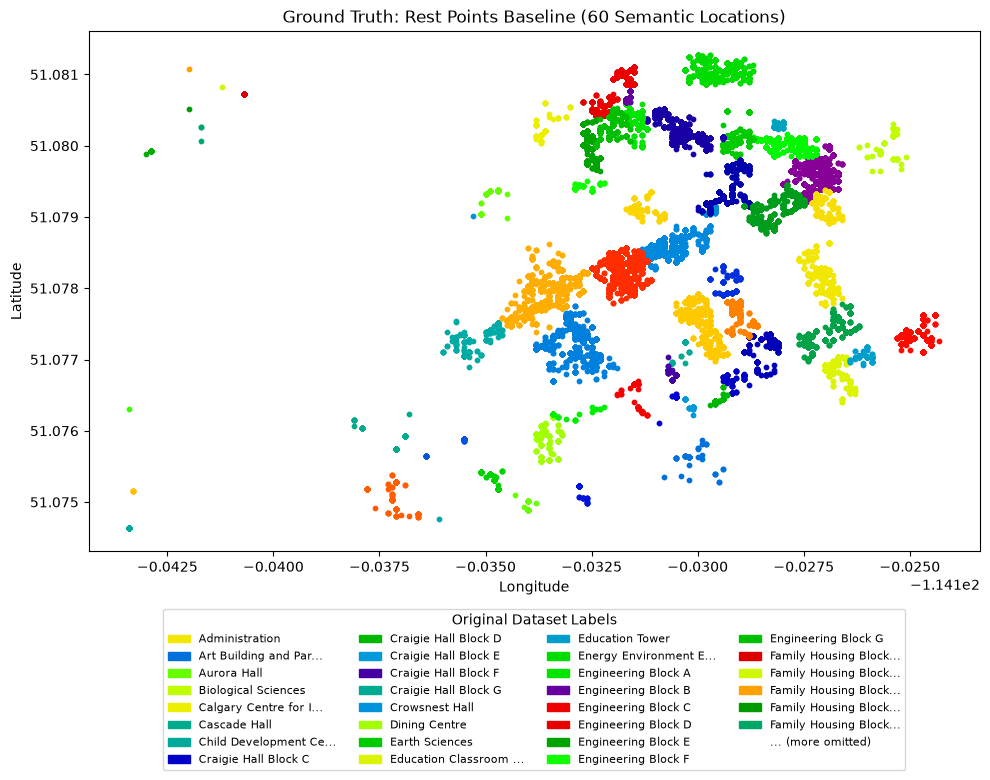

In [10]:
# 0. Establish the Ground Truth Visual Baseline
print("--- Establishing Ground Truth ---")
plot_ground_truth(df_rest, "Rest Points Baseline")

In [3]:
def get_safe_filename(title):
    return "".join([c if c.isalnum() else "_" for c in title]).replace("__", "_").lower()

def run_dbscan_and_plot(df, title, eps_m=12.0, min_pts=60):
    if df.empty: return
    coords = np.radians(df[["lat", "lon"]].values)
    db = DBSCAN(eps=eps_m / EARTH_RADIUS_METERS, min_samples=min_pts, metric="haversine")
    df["cluster"] = db.fit_predict(coords)
    
    mask = df["cluster"] != -1
    unique_clusters = sorted(df.loc[mask, "cluster"].unique())
    n_clusters = len(unique_clusters)

    fig, ax = plt.subplots(figsize=(10, 8))
    color_array = plt.cm.nipy_spectral(np.linspace(0.1, 0.9, max(n_clusters, 1)))
    np.random.seed(42)
    np.random.shuffle(color_array)
    color_dict = {c: color_array[i] for i, c in enumerate(unique_clusters)}
    df.loc[mask, "plot_color"] = df.loc[mask, "cluster"].map(color_dict)

    ax.scatter(df.loc[~mask, "lon"], df.loc[~mask, "lat"], c="lightgrey", s=2, alpha=0.3, label="Noise")
    if not df[mask].empty:
        ax.scatter(df.loc[mask, "lon"], df.loc[mask, "lat"], c=list(df.loc[mask, "plot_color"]), s=10)
    
    ax.set_title(f"Spatial DBSCAN: {title} ({n_clusters} Clusters)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

    handles = [mpatches.Patch(color="lightgrey", label="Noise (-1)")]
    for c in unique_clusters[:30]:
        handles.append(mpatches.Patch(color=color_dict[c], label=f"Cluster {c}"))
    if len(unique_clusters) > 30: handles.append(mpatches.Patch(color="white", label="..."))

    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=8)
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"{get_safe_filename(title)}.png"), dpi=300, bbox_inches="tight")
    plt.show()

def run_st_dbscan_and_plot(df, title, eps_m=12.0, eps_sec=1800, min_pts=30):
    if df.empty: return
    coords = np.radians(df[["lat", "lon"]].values)
    times = df["epoch_sec"].values
    n = len(df)
    
    tree = BallTree(coords, metric="haversine")
    spatial_neighbors = tree.query_radius(coords, r=eps_m / EARTH_RADIUS_METERS)
    labels, visited, cluster_id = np.full(n, -1, dtype=int), np.zeros(n, dtype=bool), 0

    for i in range(n):
        if visited[i]: continue
        visited[i] = True
        cand = spatial_neighbors[i]
        st_neighbors = cand[np.abs(times[cand] - times[i]) <= eps_sec]
        
        if len(st_neighbors) >= min_pts:
            cluster_id += 1
            labels[i] = cluster_id
            seed_set = list(st_neighbors[st_neighbors != i])
            while seed_set:
                curr = seed_set.pop(0)
                if not visited[curr]:
                    visited[curr] = True
                    c_cand = spatial_neighbors[curr]
                    c_st = c_cand[np.abs(times[c_cand] - times[curr]) <= eps_sec]
                    if len(c_st) >= min_pts:
                        seed_set.extend([p for p in c_st if p not in seed_set and not visited[p]])
                if labels[curr] == -1: labels[curr] = cluster_id
                    
    df["st_cluster"] = labels
    mask_st = df["st_cluster"] != -1
    unique_st = sorted(df.loc[mask_st, "st_cluster"].unique())

    fig, ax = plt.subplots(figsize=(10, 8))
    color_array = plt.cm.turbo(np.linspace(0.1, 0.9, max(len(unique_st), 1)))
    np.random.seed(42)
    np.random.shuffle(color_array)
    color_dict = {c: color_array[i] for i, c in enumerate(unique_st)}

    ax.scatter(df.loc[~mask_st, "lon"], df.loc[~mask_st, "lat"], c="lightgrey", s=2, alpha=0.3)
    if not df[mask_st].empty:
        df.loc[mask_st, "plot_color"] = df.loc[mask_st, "st_cluster"].map(color_dict)
        ax.scatter(df.loc[mask_st, "lon"], df.loc[mask_st, "lat"], c=list(df.loc[mask_st, "plot_color"]), s=10)
    
    ax.set_title(f"ST-DBSCAN: {title} ({cluster_id} Events)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

    handles = [mpatches.Patch(color="lightgrey", label="Noise (-1)")]
    for c in unique_st[:30]: handles.append(mpatches.Patch(color=color_dict[c], label=f"Time Event {c}"))
    if len(unique_st) > 30: handles.append(mpatches.Patch(color="white", label="..."))

    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=8)
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"{get_safe_filename(title)}.png"), dpi=300, bbox_inches="tight")
    plt.show()

def run_kde_and_plot(df, title):
    if df.empty: return
    fig, ax = plt.subplots(figsize=(10, 8))
    plot_df = df.sample(min(20000, len(df)), random_state=42)
    
    x, y = plot_df["lon"].values, plot_df["lat"].values
    kde = gaussian_kde(np.vstack([x, y]))
    xi, yi = np.mgrid[x.min():x.max():150j, y.min():y.max():150j]
    zi = kde(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
    
    contour = ax.contourf(xi, yi, zi, levels=20, cmap="inferno")
    ax.set_title(f"KDE Density: {title}")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    cbar = fig.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Density Intensity', rotation=270, labelpad=15)
    
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"{get_safe_filename(title)}.png"), dpi=300)
    plt.show()

--- Generating Baseline Models ---


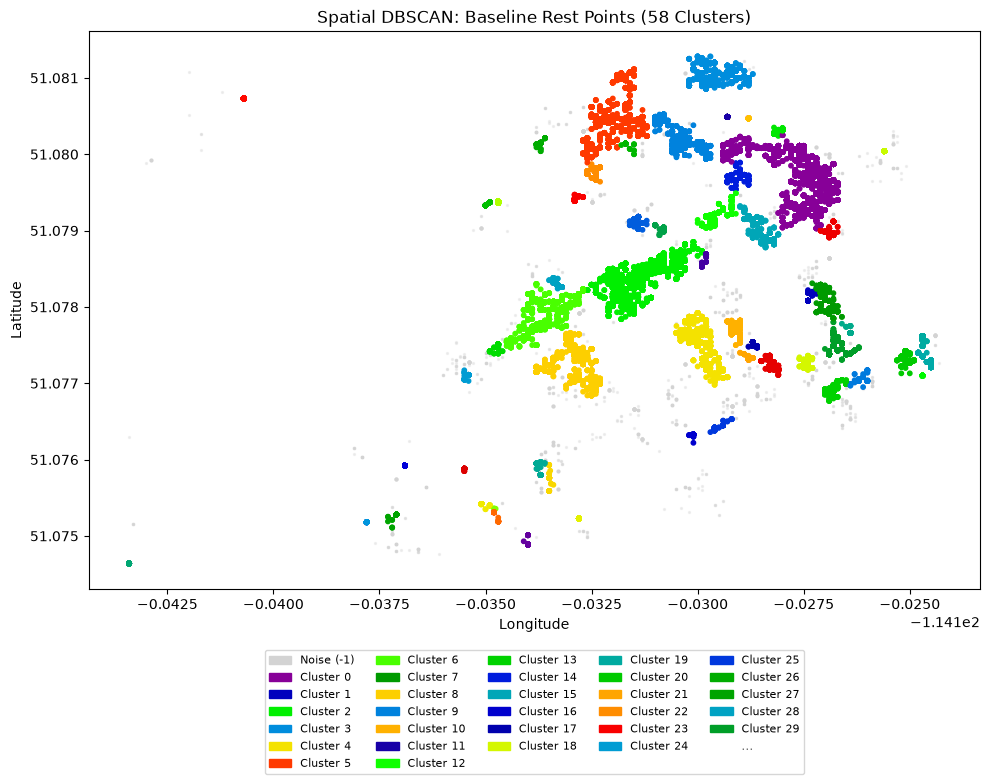

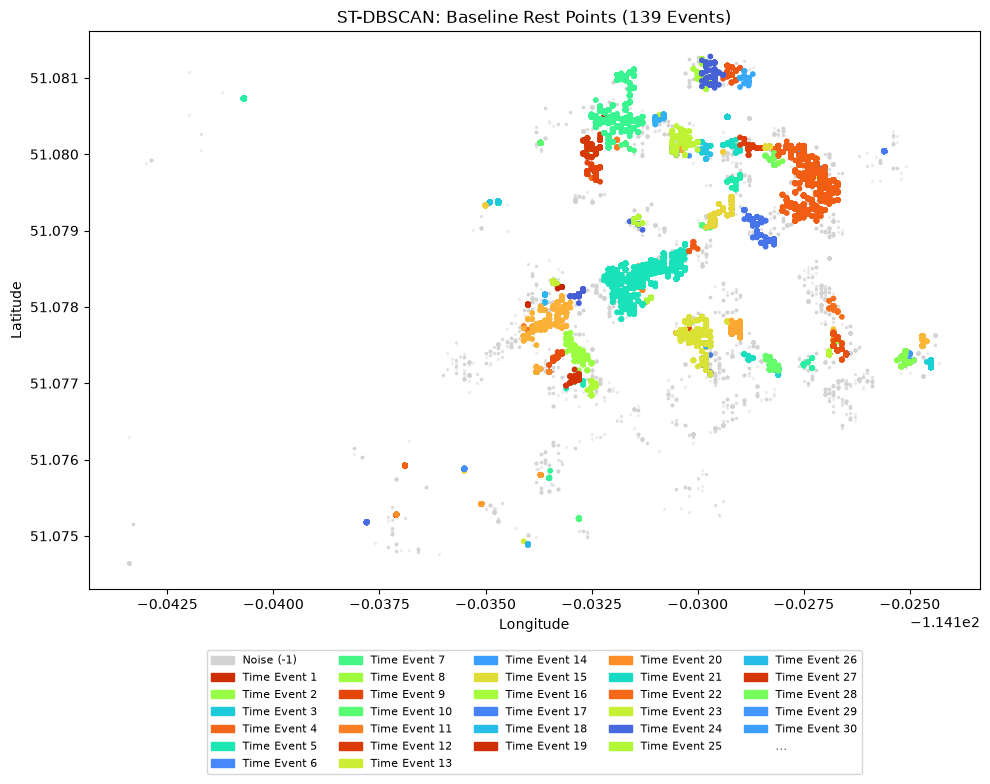

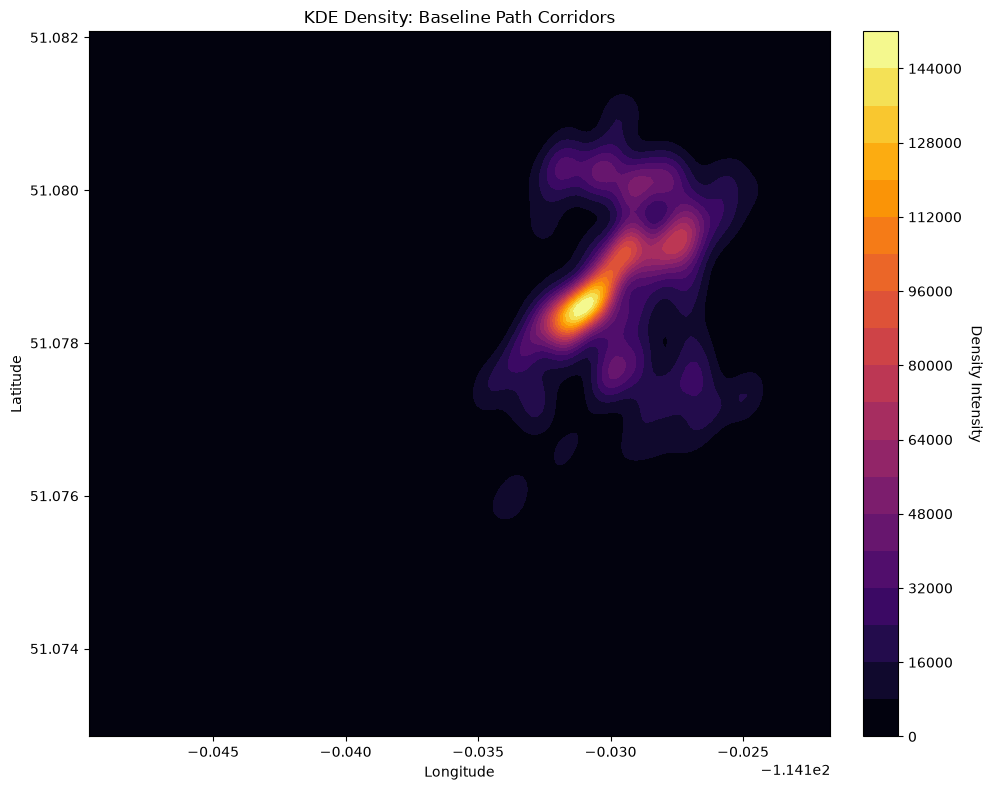

In [4]:
# 1. Standard Analysis on Full Datasets
print("--- Generating Baseline Models ---")
run_dbscan_and_plot(df_rest, "Baseline Rest Points", eps_m=12.0, min_pts=60)
run_st_dbscan_and_plot(df_rest, "Baseline Rest Points", eps_m=12.0, eps_sec=1800, min_pts=30)
run_kde_and_plot(df_path, "Baseline Path Corridors")

--- Generating Behavioral Clusters ---


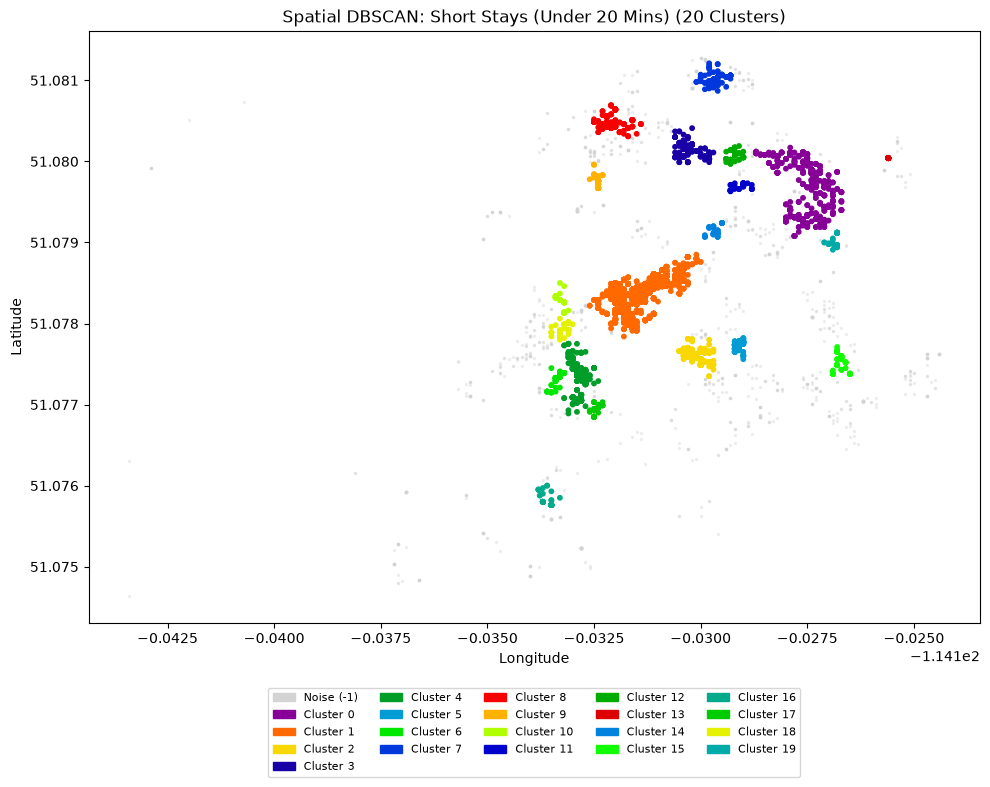

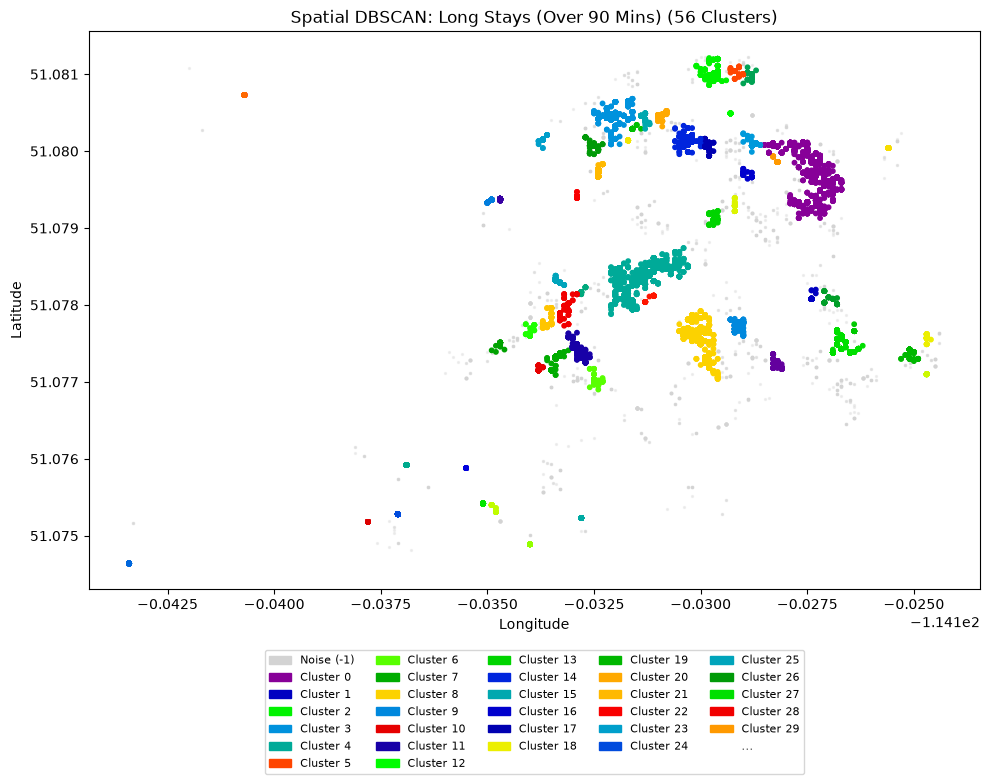

In [5]:
# 2. Filtering by Stay Duration
print("--- Generating Behavioral Clusters ---")
short_stay = df_rest[df_rest["duration_m"] <= 20]
long_stay = df_rest[df_rest["duration_m"] >= 90]

run_dbscan_and_plot(short_stay, "Short Stays (Under 20 Mins)", eps_m=15.0, min_pts=30)
run_dbscan_and_plot(long_stay, "Long Stays (Over 90 Mins)", eps_m=12.0, min_pts=40)

--- Generating Weather Clusters ---


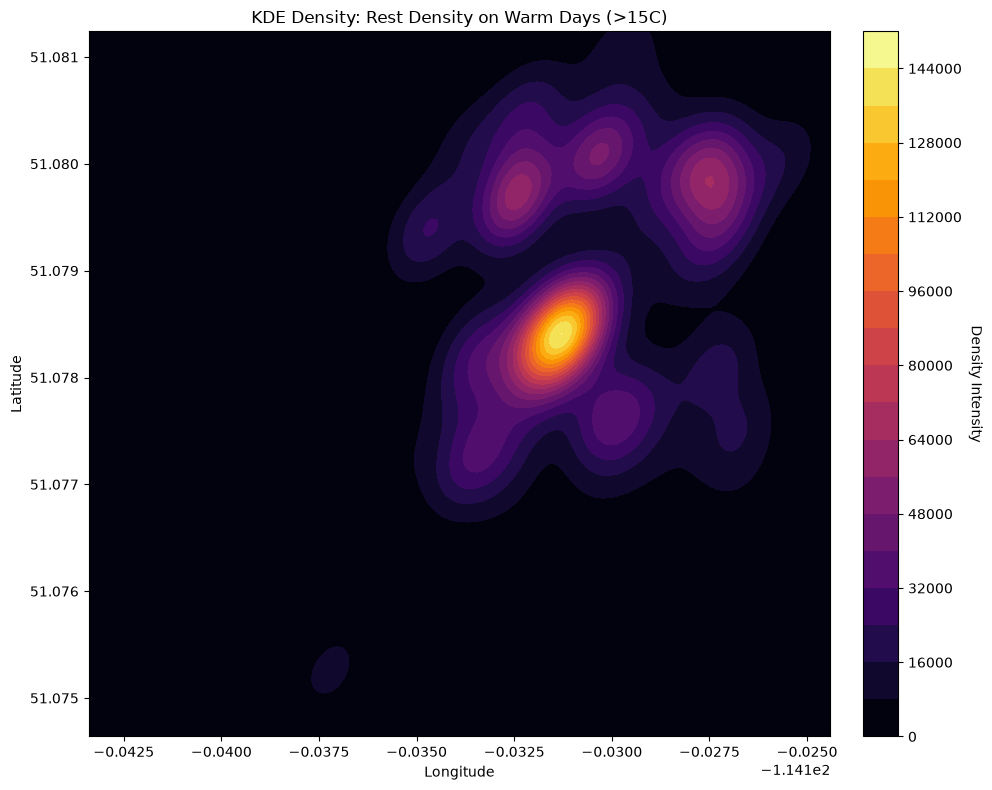

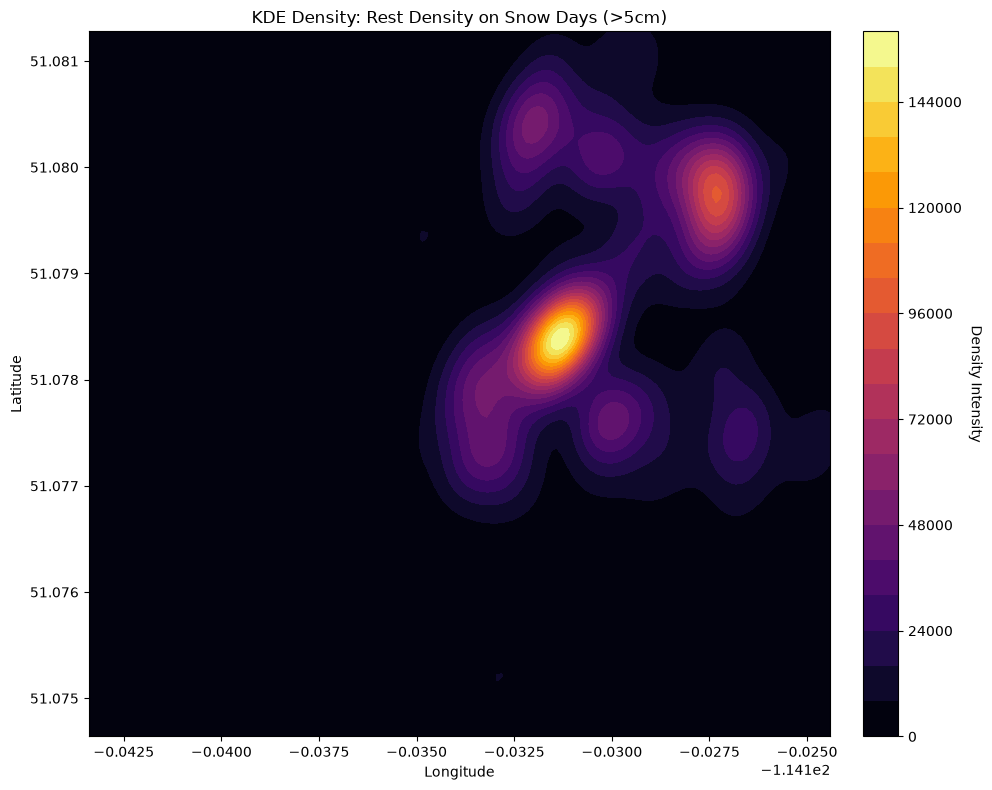

In [6]:
# 3. Filtering by Weather Conditions
print("--- Generating Weather Clusters ---")
warm_days = df_rest[df_rest["temp_c"] > 15]
snow_days = df_rest[df_rest["snow_cm"] > 5]

# Using KDE on Rest points to show how indoor/outdoor clustering density shifts purely based on weather
run_kde_and_plot(warm_days, "Rest Density on Warm Days (>15C)")
run_kde_and_plot(snow_days, "Rest Density on Snow Days (>5cm)")

--- Generating Time-of-Day Clusters ---


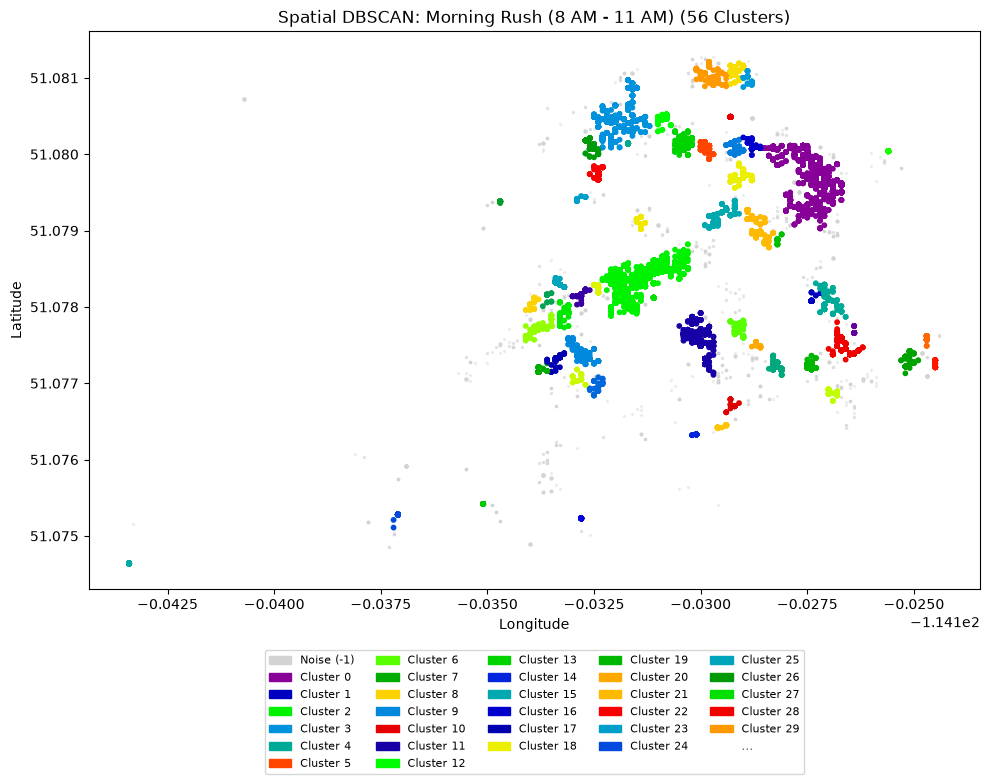

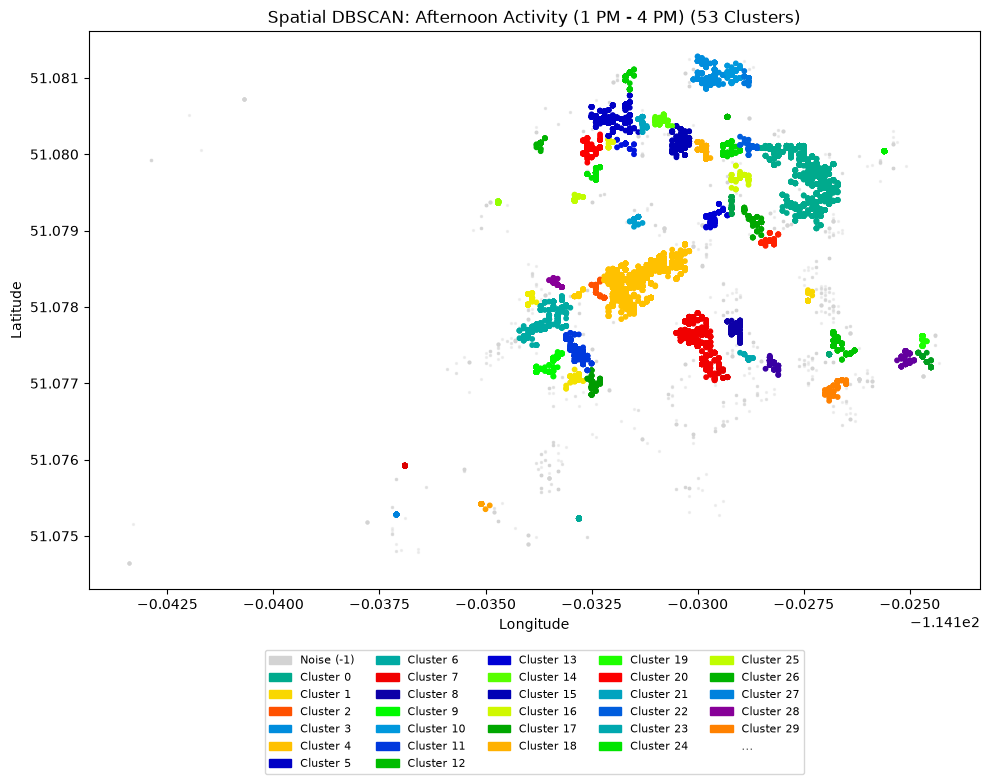

In [7]:
# 4. Filtering by Campus Hour (Heartbeat)
print("--- Generating Time-of-Day Clusters ---")
morning_rush = df_rest[(df_rest["hour"] >= 8) & (df_rest["hour"] <= 11)]
afternoon_lull = df_rest[(df_rest["hour"] >= 13) & (df_rest["hour"] <= 16)]

run_dbscan_and_plot(morning_rush, "Morning Rush (8 AM - 11 AM)", eps_m=12.0, min_pts=40)
run_dbscan_and_plot(afternoon_lull, "Afternoon Activity (1 PM - 4 PM)", eps_m=12.0, min_pts=40)

--- Generating Seasonal Clusters ---


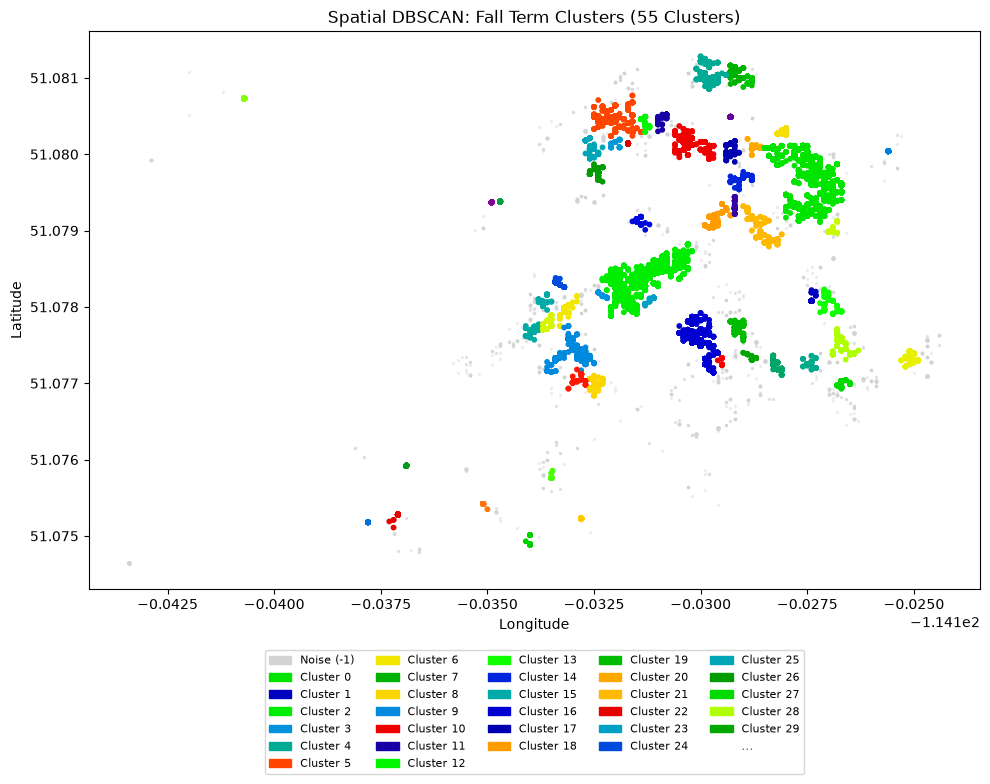

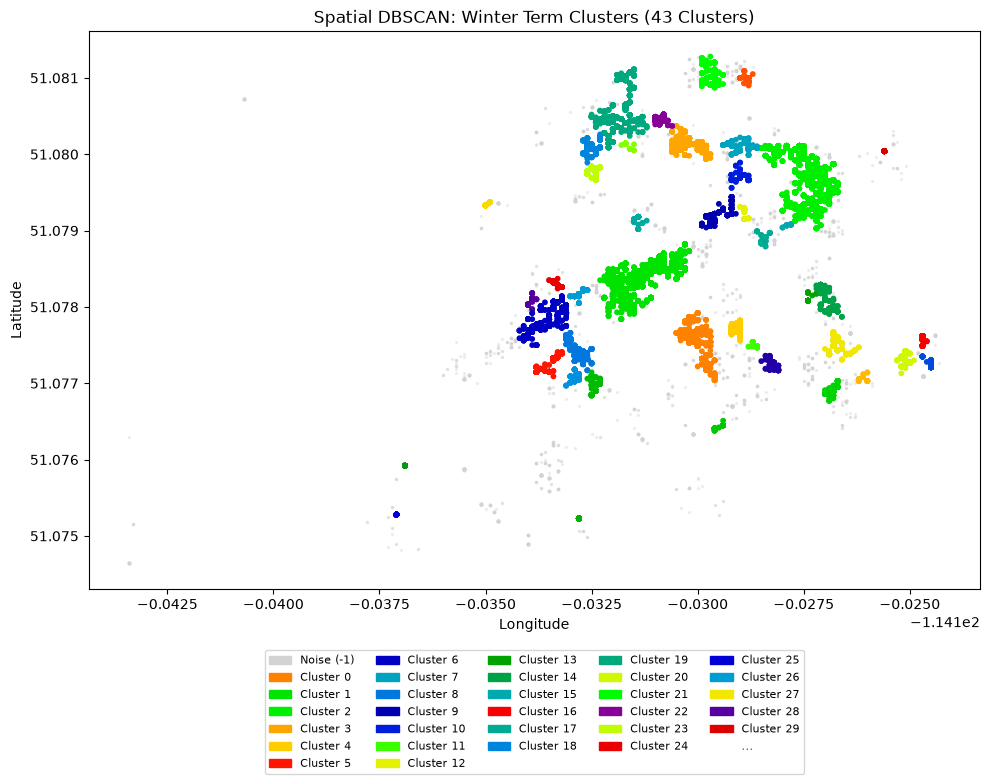

In [8]:
# 5. Filtering by Academic Term
print("--- Generating Seasonal Clusters ---")
# Adjust these strings if your dataset uses different term naming conventions
fall_term = df_rest[df_rest["term"].str.contains("FALL", na=False, case=False)]
winter_term = df_rest[df_rest["term"].str.contains("WINTER", na=False, case=False)]

run_dbscan_and_plot(fall_term, "Fall Term Clusters", eps_m=12.0, min_pts=50)
run_dbscan_and_plot(winter_term, "Winter Term Clusters", eps_m=12.0, min_pts=50)